In [1]:
## Python single cell stack


import scanpy as sc
import scvi 
import torch
from scvi.external import CellAssign
import pandas as pd
import numpy as np
import scipy
from scipy import sparse

## Plotting

import matplotlib.pyplot as plt
import seaborn as sns

## Paths and system

import os, sys

from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))
from src.config import ANALYSIS_DIR, FIGURES_DIR, UTILITIES_DIR


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Settings for our scanpy modules

In [2]:
sc.settings.autosave = True       
sc.settings.figdir = str(FIGURES_DIR / "cell-assign/d2-dz")
scvi.settings.seed = 0


Seed set to 0


### Change to analysis folder, and load in our data

In [3]:

d2_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "clustered_egfDuod_D2_DZ.h5ad")

In [4]:
d2_dz_clustered

## Our 'layers' contains raw 'counts'

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [5]:
### We import markers of our cell types that are first compiled from Zeve 2022, and Gui Ramos' custom 'Secretory PCs', and 'EE' markers

### Later, we will rerun the analysis with

In [7]:
cell_type_markers = pd.read_csv(UTILITIES_DIR / "new_isc_cellassign_marker_matrix.csv", index_col=0)

### We drop cell markers that aren't expressed in the data

cell_type_markers = cell_type_markers.drop(['INSM1', 'NEUROG3', 'PAX4'])


## Working with the 'counts' layer, we calculate a 'size factor', based on the raw counts. 

In [8]:
lib_size = d2_dz_clustered.layers['counts'].sum(1)
if sparse.issparse(lib_size):
    lib_size = lib_size.A1
d2_dz_clustered.obs["size_factor"] = lib_size / np.mean(lib_size)

In [9]:
filtered_d2 = d2_dz_clustered[:, cell_type_markers.index].copy()


## Specify the model, and train it

In [27]:
## Make sure that you specify the layer as 'counts'
## let's see what happens when we don't specify counts as the layer
scvi.external.CellAssign.setup_anndata(filtered_d2, layer="counts", size_factor_key="size_factor")


In [28]:
d2_model = CellAssign(filtered_d2, cell_type_markers)
d2_model.train()

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoa

Epoch 371/400:  93%|█████████▎| 371/400 [06:02<00:28,  1.02it/s, v_num=1, train_loss=7.58]
Monitored metric elbo_validation did not improve in the last 15 records. Best score: 7.676. Signaling Trainer to stop.


<Axes: xlabel='epoch'>

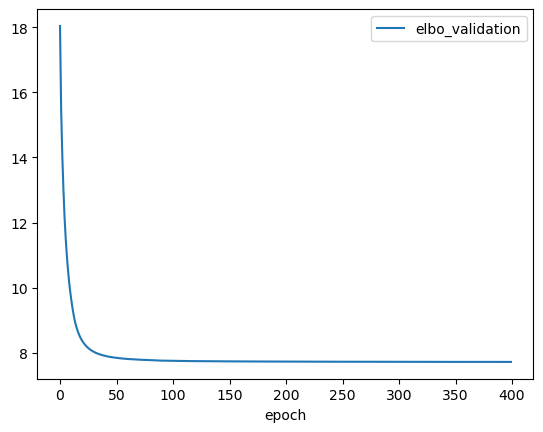

In [ ]:
d2_model.history["elbo_validation"].plot()


### Extract the cell type predictions, and save these as a separate dataframe.

In [ ]:
predictions = d2_model.predict()
predictions.head()

,ISCs,PCs,Proliferating PCs,Secretory PCs,Enterocytes,Goblet cells,EECs
0,2.204356e-08,1.505672e-07,4.370069e-08,6.303727e-07,0.000643,0.999355,1.187141e-06
1,2.028940e-08,1.380806e-07,3.382753e-06,2.925817e-06,0.001657,0.998336,3.745726e-08
2,1.265641e-07,2.021347e-07,8.006211e-07,1.075586e-05,0.001799,0.998189,7.750474e-08
3,1.571986e-10,1.544500e-07,3.890154e-06,4.689272e-06,0.001595,0.998396,3.153658e-08
4,1.319513e-17,6.572086e-08,4.052914e-07,2.584692e-05,0.001489,0.998485,1.169841e-08


In [ ]:
predictions.describe()

,ISCs,PCs,Proliferating PCs,Secretory PCs,Enterocytes,Goblet cells,EECs
count,4.621000e+04,4.621000e+04,4.621000e+04,4.621000e+04,4.621000e+04,4.621000e+04,4.621000e+04
mean,1.545247e-04,3.664178e-06,9.531329e-05,3.702551e-04,1.899295e-02,9.803808e-01,2.522569e-06
std,1.097410e-02,9.560505e-05,2.484049e-03,1.414175e-02,1.282606e-01,1.306562e-01,2.002908e-04
min,4.119763e-35,1.255803e-30,2.450370e-32,1.682761e-29,1.811118e-08,4.163327e-24,5.470001e-32
25%,2.641423e-16,4.727125e-08,2.572058e-08,6.581730e-07,8.121968e-04,9.984325e-01,1.152695e-08
50%,1.936172e-08,8.966082e-08,9.131020e-07,2.883767e-06,1.254138e-03,9.987286e-01,1.793930e-08
75%,7.392039e-08,2.309762e-07,2.950050e-06,4.487223e-06,1.545516e-03,9.991735e-01,9.270532e-08
max,9.999390e-01,9.708678e-03,2.428096e-01,9.999561e-01,1.000000e+00,9.999542e-01,3.999210e-02


In [26]:
## save the dataframe

os.getcwd()
predictions.to_csv(str(ANALYSIS_DIR / "cell_assign_dfs/d2_probabilities.csv"), index=True)

### Create an average score for each cluster, and plot that using a heatmap

In [ ]:

predictions.shape[0], filtered_d2.n_obs
predictions.index[:3], filtered_d2.obs_names[:3]
predictions.index.equals(pd.Index(filtered_d2.obs_names))


False

In [ ]:
for col in predictions.columns:
    filtered_d2.obs[f"cell_assign_prob_{col}"] = predictions[col].to_numpy()
filtered_d2.obs["initial_cellassign_prediction"] = predictions.idxmax(axis=1).to_numpy()
filtered_d2.obs["cellassign_confidence"] = predictions.max(axis=1).to_numpy()


In [ ]:
filtered_d2.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden,...,_scvi_batch,cell_assign_prob_ISCs,cell_assign_prob_PCs,cell_assign_prob_Proliferating PCs,cell_assign_prob_Secretory PCs,cell_assign_prob_Enterocytes,cell_assign_prob_Goblet cells,cell_assign_prob_EECs,initial_cellassign_prediction,cellassign_confidence
AAACCAAAGATACTCG-1,D2,836.0,665,Negative,Negative,G2D2,G2D2,Untreated,D2,11,...,0,2.204356e-08,1.505672e-07,4.370069e-08,6.303727e-07,0.000643,0.999355,1.187141e-06,Goblet cells,0.999355
AAACCAAAGCCAACTA-1,D2,4748.0,2337,2,H897,G2D2,G2D2,Untreated,D2,2,...,0,2.028940e-08,1.380806e-07,3.382753e-06,2.925817e-06,0.001657,0.998336,3.745726e-08,Goblet cells,0.998336
AAACCAAAGGCACACT-1,D2,3957.0,1911,2,H897,G2D2,G2D2,Untreated,D2,2,...,0,1.265641e-07,2.021347e-07,8.006211e-07,1.075586e-05,0.001799,0.998189,7.750474e-08,Goblet cells,0.998189
AAACCAAAGGTGCTCG-1,D2,4934.0,2292,1,H896,G2D2,G2D2,Untreated,D2,4,...,0,1.571986e-10,1.544500e-07,3.890154e-06,4.689272e-06,0.001595,0.998396,3.153658e-08,Goblet cells,0.998396
AAACCAAAGTCAACTG-1,D2,10380.0,3749,1,H896,G2D2,G2D2,Untreated,D2,5,...,0,1.319513e-17,6.572086e-08,4.052914e-07,2.584692e-05,0.001489,0.998485,1.169841e-08,Goblet cells,0.998485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGGTATAGA-1,D2,7473.0,3086,0,H329,G2D2,G2D2,Untreated,D2,1,...,0,1.032932e-17,7.658206e-08,1.902851e-06,1.285836e-05,0.001179,0.998806,7.812525e-09,Goblet cells,0.998806
TGTGTTGAGTAATCAC-1,D2,10060.0,3149,0,H329,G2D2,G2D2,Untreated,D2,1,...,0,1.949182e-06,6.851273e-08,1.681271e-06,4.225240e-06,0.001548,0.998444,1.142894e-08,Goblet cells,0.998444
TGTGTTGAGTAGTTCG-1,D2,9850.0,3346,0,H329,G2D2,G2D2,Untreated,D2,1,...,0,2.228663e-17,2.988742e-07,4.972480e-06,2.526761e-05,0.001582,0.998388,1.124351e-08,Goblet cells,0.998388
TGTGTTGAGTCGCGTG-1,D2,3967.0,2007,0,H329,G2D2,G2D2,Untreated,D2,2,...,0,2.526420e-08,2.023226e-07,8.106397e-07,2.524149e-06,0.001800,0.998196,7.688429e-08,Goblet cells,0.998196


In [ ]:

cluster_col = "leiden"  

# identify the CellAssign probability columns
prob_cols = [c for c in filtered_d2.obs.columns if c.startswith("cell_assign_prob_")]

# compute per-cluster means
cluster_means = (
    filtered_d2.obs
    .groupby(cluster_col)[prob_cols]
    .mean()
)

print(cluster_means.round(3))  # print nicely rounded


        cell_assign_prob_ISCs  cell_assign_prob_PCs  \
leiden                                                
0                       0.001                   0.0   
1                       0.000                   0.0   
2                       0.000                   0.0   
3                       0.000                   0.0   
4                       0.000                   0.0   
5                       0.000                   0.0   
6                       0.000                   0.0   
7                       0.000                   0.0   
8                       0.000                   0.0   
9                       0.000                   0.0   
10                      0.000                   0.0   
11                      0.000                   0.0   
12                      0.000                   0.0   
13                      0.000                   0.0   
14                      0.000                   0.0   
15                      0.000                   0.0   
16        

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_15468/391197902.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_col)[prob_cols]


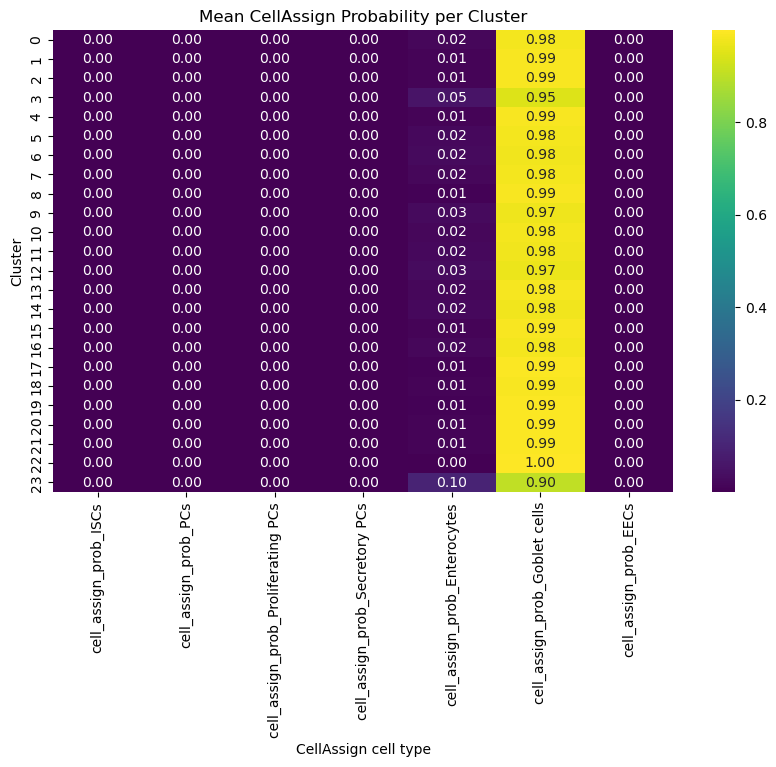

In [ ]:


plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, cmap="viridis", annot=True, fmt=".2f")
plt.title("Mean CellAssign Probability per Cluster")
plt.xlabel("CellAssign cell type")
plt.ylabel("Cluster")
plt.show()


### Let's look at where these clusters are in UMAP space, against these predicted labels

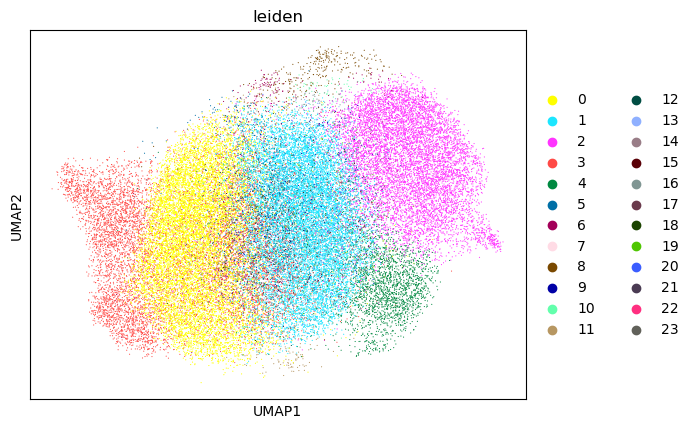

In [21]:
sc.pl.umap(d2_dz_clustered, color = 'leiden', palette=sc.pl.palettes.default_102, save=False # or sc.pl.palettes.zeileis_28
)

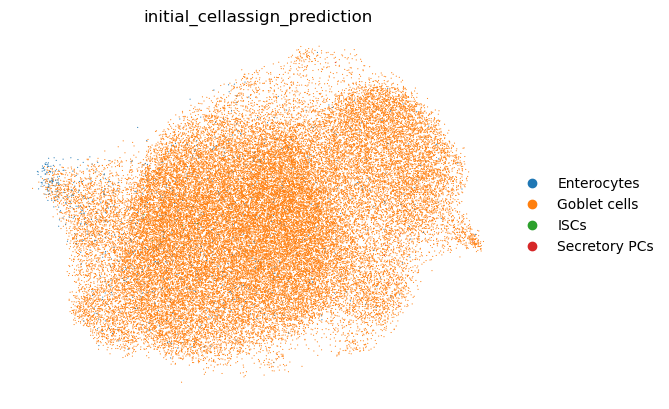

In [22]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    filtered_d2,
    color="initial_cellassign_prediction",
    frameon=False,
    ncols=1,
    save=False
)